In [ ]:
# Standard library
import random

# Data manipulation
import numpy as np
import pandas as pd
import geopandas as gpd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_percentage_error,
    r2_score
)
from sklearn.model_selection import (
    KFold)
from sklearn.preprocessing import StandardScaler

# Custom utilities
import utils.cross_validation as cval

from math import radians, sin, cos, sqrt, asin


In [ ]:
biome_mapping = {
        0: 'Boreal and Tundra forests',
        1: 'Flooded grasslands',
        2: 'Mangroves',
        3: 'Mediterranean woodlands',
        4: 'Temperate broadleaf forests',
        5: 'Temperate conifer forests',
        6: 'Temperate grasslands',
        7: 'Tropical',
        8: 'Tropical',
        9: 'Tropical',
        10: 'Tropical',
        11: 'Boreal and Tundra forests',
        12: 'Xeric shrublands',
        13: 'Unknown'
    }

biome_colors = {
    'Boreal and Tundra forests': "#62D7E0",        # boreal blue
    'Flooded grasslands': "#4CAF50",                # wetland green
    'Mangroves': "#2E7D32",                        # coastal green
    'Mediterranean woodlands': "#F4A460",          # sandy brown
    'Temperate broadleaf forests': "#1B3111",      # dark temperate green
    'Temperate conifer forests': "#7E34A9",        # purple conifer
    'Temperate grasslands': "#D4A843",             # golden
    'Tropical': "#079331",                         # tropical green
    'Xeric shrublands': "#D2691E",                 # desert brown
    }


def data_processing_v2(df, biome_mapping, ecoregions):
     
    # df = df[df['biome'].isin([4,5,6,12])]

    df["biome"] = df["biome"].replace(biome_mapping)

    df=cval.assign_spatial_groups(df, grid_size=1.0)

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"  # WGS84
    )

    joined = gpd.sjoin(gdf, ecoregions, how="left", predicate="within")

    biome_dfs = {k: v for k, v in joined.groupby('biome')}
    return biome_dfs


def train_rf_cv(X, y, n_splits=5, rf_params=None):
    if rf_params is None:
        rf_params = {
            'n_estimators': 200,
            'max_depth': None,
            'min_samples_leaf': 2,
            'n_jobs': -1,
            'random_state': 42
        }

    # Fix: reset index to avoid positional/label index mismatch
    X = np.array(X)
    y = np.array(y)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    model = RandomForestRegressor(**rf_params)

    fold_mape, fold_r2, fold_y_val= [], [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        X_train, X_val = X[train_idx], X[val_idx]  # use .iloc
        y_train, y_val = y[train_idx], y[val_idx]  # use .iloc

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        mape = mean_absolute_percentage_error(y_val, y_pred, multioutput='raw_values')
        r2  = r2_score(y_val, y_pred, multioutput='raw_values')
        y_mean = np.mean(y_val)
        fold_mape.append(mape)
        fold_r2.append(r2)
        fold_y_val.append(y_mean)
        
    fold_mape = np.array(fold_mape)
    fold_r2 = [float(x[0]) if isinstance(x, np.ndarray) else x for x in fold_r2]
    # fold_r2 = list(fold_r2)

    return model, fold_mape, fold_r2, fold_y_val


def haversine(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points in km"""
    R = 6371  # Earth's radius in km
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    
    return R * c


def select_points_with_buffer(df, n_points, buffer_km=100, lat_col='lat', lon_col='lon', 
                              random_seed=None):
    """
    Randomly select n_points and remove any points within buffer_km of selected points
    
    Parameters:
    - df: DataFrame with coordinates
    - n_points: number of points to randomly select
    - buffer_km: buffer radius in kilometers (default: 100)
    - lat_col: name of latitude column
    - lon_col: name of longitude column
    - random_seed: random seed for reproducibility
    
    Returns:
    - selected: DataFrame of selected points
    - remaining: DataFrame of points outside buffer
    - removed: DataFrame of points within buffer of selected points
    """
    
    if random_seed is not None:
        np.random.seed(random_seed)
        random.seed(random_seed)
    
    # Get unique coordinates (if multiple rows per location)
    coords = df[[lat_col, lon_col]].drop_duplicates().reset_index(drop=True)
    
    if len(coords) < n_points:
        raise ValueError(f"Only {len(coords)} unique points available, but {n_points} requested")
    
    # Randomly select n_points
    selected_indices = np.random.choice(len(coords), n_points, replace=False)
    selected_coords = coords.iloc[selected_indices].copy()
    
    # Identify points within buffer
    selected_points = []
    removed_points = []
    remaining_points = []
    
    for idx, row in coords.iterrows():
        lat = row[lat_col]
        lon = row[lon_col]
        
        # Check distance to all selected points
        within_buffer = False
        for _, sel_row in selected_coords.iterrows():
            dist = haversine(lat, lon, sel_row[lat_col], sel_row[lon_col])
            if dist <= buffer_km:
                within_buffer = True
                break
        
        if idx in selected_indices:
            selected_points.append(idx)
        elif within_buffer:
            removed_points.append(idx)
        else:
            remaining_points.append(idx)
    
    # Create DataFrames
    selected_df = df.iloc[selected_points].copy()
    removed_df = df.iloc[removed_points].copy()
    remaining_df = df.iloc[remaining_points].copy()
    
    return selected_df, remaining_df, removed_df


def train_test_split(df, random_key, n_points_to_select=50, buffer_km=100):
    sub_df = df.drop(columns=['biome', 'managed.1', 'lon_bin', 'lat_bin', 'geometry',
       'index_right', ])

    
    random_key =10

    selected, remaining, removed = select_points_with_buffer(
        sub_df, 
        n_points=n_points_to_select,
        buffer_km=buffer_km,
        lat_col='lat',
        lon_col='lon',
        random_seed=random_key
    )

    test = selected.drop(columns=['lat', 'lon'])
    train= remaining.drop(columns=['lat', 'lon'])

    y=['transformed npp'] 
    X_train=train.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
    y_train = train['transformed npp'].values

    X_test= test.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
    y_test = test['transformed npp'].values
    
    scaler= StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    return X_train, y_train, X_test, y_test


In [ ]:
fd_df = pd.read_csv('data/final/final_dataset.csv')

fd_df.drop(columns=['TPA_UNADJ','DIA_x', 'biome.1', 'ownership.1', 'BHAGE'], inplace=True)
fd_df.dropna(inplace=True)


ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]

#Preprocessing the data for Random forest regression
fbiome_dfs= data_processing_v2(fd_df, biome_mapping, ecoregions)


In [50]:
biomes_list=['Temperate conifer forests',
            'Temperate grasslands', 'Tropical', 'Unknown', 'Mediterranean woodlands', 
            'Xeric shrublands', 'Temperate broadleaf forests', 'Boreal and Tundra forests']
 

results_df=pd.DataFrame(columns=['biome', 'mape', 'r2', 'Stability'])

for biome in biomes_list:
    print(f"Biome: {biome}")

    random.seed(42)
    random_keys = [random.randint(0, 500) for _ in range(2)]

    for key in random_keys:
        random_key=key
        n_points= round(len(fbiome_dfs[biome])*0.1)
        fX_train, fy_train, fX_test, fy_test = train_test_split(fbiome_dfs[biome], random_key=random_key, n_points_to_select=n_points, buffer_km=50)
        # sX_train, sy_train, sX_test, sy_test = train_test_split(sbiome_dfs[biome], random_key=27, test_size=0.4)
        
        fmodel, mape, r2, y_val = train_rf_cv(fX_train, fy_train, n_splits=10)

        mape = [item[0] for item in mape]
        r2 = r2
        
        sub_df = pd.DataFrame(
            list(zip([biome]*len(mape), mape, r2, y_val)),
            columns=['biome', 'mape', 'r2', 'Stability']
        )
        results_df=pd.concat([results_df, sub_df], ignore_index=True)

Biome: Temperate conifer forests
Biome: Temperate grasslands
Biome: Tropical
Biome: Unknown
Biome: Mediterranean woodlands
Biome: Xeric shrublands
Biome: Temperate broadleaf forests


/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Biome: Boreal and Tundra forests


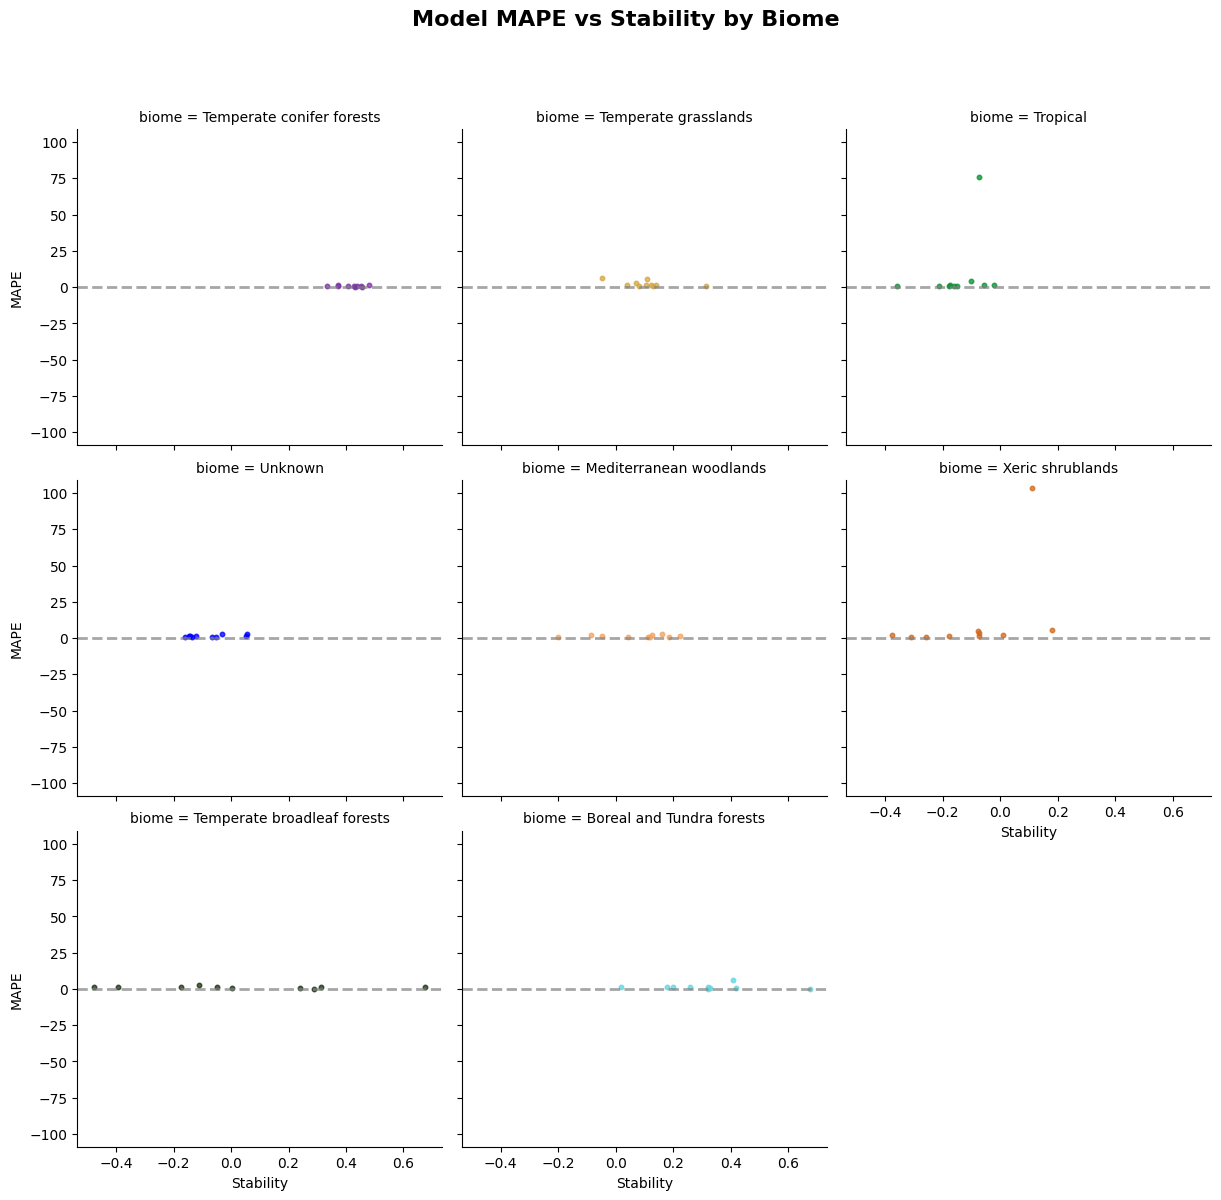

In [ ]:

# Create FacetGrid with scatter plots
g = sns.FacetGrid(
    results_df, 
    col="biome", 
    col_wrap=3, 
    height=4, 
    sharex=True, 
    sharey=True
)

# Map scatter plot with biome-specific colors
# Use a custom function to apply colors from biome_colors dict
def scatter_with_color(data, **kwargs):
    # Get the biome name for this facet
    biome_name = data['biome'].iloc[0]
    color = biome_colors.get(biome_name, 'blue')  # Default to blue if not found
    plt.scatter(data['Stability'], data['mape'], 
               color=color, alpha=0.5, s=10)

g.map_dataframe(scatter_with_color)

# Add MAPE=0 line centered in each subplot
for ax in g.axes.flat:
    # Get y-axis limits
    ymin, ymax = ax.get_ylim()
    
    # Center the y-axis around 0 if needed
    max_abs = max(abs(ymin), abs(ymax))
    ax.set_ylim(-max_abs, max_abs)  # Center at 0
    
    # Add horizontal line at MAPE=0
    ax.axhline(y=0, color='gray', linewidth=2, linestyle='--', alpha=0.7)

# Set axis labels
g.set_axis_labels("Stability", "MAPE")

# Adjust spacing - MORE SPACE between title and subplots
g.fig.subplots_adjust(top=0.88)  # Increased from 0.9 to 0.88 (more space)

# Add title with more space
g.fig.suptitle(
    'Model MAPE vs Stability by Biome', 
    fontsize=16, 
    fontweight='bold',
    y=0.98  # Adjust y position (0.98 = higher, more space below)
)

plt.show()